# Machine Learning for Systems Neuroscience

<div align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/a/a9/Belisaire_demandant_l'aumone_Jacques-Louis_David.jpg/1280px-Belisaire_demandant_l'aumone_Jacques-Louis_David.jpg?utm_source=en.wikipedia.org&utm_campaign=index&utm_content=thumbnail" alt="Belisarius Begging for Alms" width="75%">

*Belisarius Begging for Alms* — Jacques-Louis David
</div>

## 1. Motivation: neural representations behind social behavior

Zhang et al. (2024) studied **allolicking**: mice lick the injury site of another mouse. This is a measurable helping behavior that gives us a way to connect social behavior with neural activity.

![Allolicking](https://cdn.jumpshare.com/preview/pfgBgYsSRR3h2VNGb9kPsIU_LObNPmub9C4B8HsD7jpLi_H9yPhlwVokifhFxAjgCVUUxIOPxHX35GSeL_pwB95d41SgpspefkE3esUcbgo)

One of the questions was **how does brain represent another animal’s state and guide an appropriate response?**

[Zhang et al., *Nature* 626, 136–144 (2024)](https://doi.org/10.1038/s41586-023-06973-x)

### Behavioral paradigm

<div align="center"><img src="https://i.ibb.co/5x4gfNNH/hong1.png" alt="Behavioral paradigm" width="80%"></div>

**Compared with saline controls, observer mice showed more targeted **allolicking** toward demonstrators whose injury was induced with melittin.**

### Calcium imaging in the anterior cingulate cortex

<div align="center"><img src="https://i.ibb.co/XZjBwVTJ/hong2.png" alt="Calcium imaging in the ACC" width="85%"></div>


The researchers used microendoscopic calcium imaging to measure activity in the **anterior cingulate cortex (ACC)** while observer mice interacted with demonstrators.

**Analysis at two levels:**

- Individual neurons can respond differently to pain-related and control conditions (e-g).
- The activity of the whole population can be used to decode the demonstrator’s state (h).

### What does decoding tell us?

A decoder treats the activity of several neurons as a feature vector and predicts a labeled condition. **Above-chance **cross-validated** performance shows that the recorded activity contains information that is useful for distinguishing the conditions.**

> Decoding is evidence for information in the measured population.

### How to approach decoding?

[Zhang et al.](https://doi.org/10.1038/s41586-023-06973-x) used **binary SVM decoders** and evaluated performance independently for each experiment with **leave-one-out cross-validation (LOOCV)**.

We will first build the ideas behind regression and classification. Later, we apply a simple linear SVM to a separate BLA calcium-imaging dataset from O’Neill et al.

# 2. Machine-learning foundations

In [ ]:
# Imports used throughout the regression and classification examples.
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import FloatLogSlider, FloatSlider, IntSlider, interact
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 2.1 Datasets, regression, overfitting.

We begin with a simple supervised-learning example: predicting body weight from height.

Each observation contains an input feature, height, and a continuous target, weight.

In [ ]:
# Download the height–weight dataset from Kaggle.
dataset_dir = kagglehub.dataset_download(
    "burnoutminer/heights-and-weights-dataset"
)
csv_files = [name for name in os.listdir(dataset_dir) if name.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("No CSV file was found in the downloaded dataset.")

csv_path = os.path.join(dataset_dir, csv_files[0])
data = pd.read_csv(csv_path, index_col=0)

# Convert the original inches/pounds columns to centimetres/kilograms.
data["Height"] = data["Height(Inches)"] * 2.54
data["Weight"] = data["Weight(Pounds)"] * 0.453592
data = data.drop(columns=["Height(Inches)", "Weight(Pounds)"])

print(f"Loaded and converted: {csv_files[0]}")
display(data.head())

This dataset contains height and weight for many people. A scatter plot lets us inspect their relationship before fitting a model.

In [ ]:
display(data.head(10))

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(data['Height'], data['Weight'], alpha=0.15, color='purple')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Height and weight in the dataset')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

For the interactive example, we select 15 observations.

In [ ]:
# Select 15 observations for the interactive fitting example.
sample_15 = data.sample(15, random_state=42)

plt.figure(figsize=(10, 6))

# Show the full dataset faintly in the background.
plt.scatter(data['Height'], data['Weight'], alpha=0.1, color='grey', label='Full dataset')

# Highlight the selected observations.
plt.scatter(sample_15['Height'], sample_15['Weight'], alpha=1.0, color='purple', s=80, edgecolors='black', label='Selected observations')

plt.xlabel('Height (cm)', fontsize=12)
plt.ylabel('Weight (kg)', fontsize=12)
plt.title('A small sample of the height–weight data')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Linear regression

Let $x$ denote the input and $t$ the observed target. For this example, a linear model is

$$y(x;w_0,w_1)=w_0+w_1x$$

The observation includes noise:

$$t_n = y(x_n;w_0,w_1) + \epsilon_n $$

Here, $x$ is height, $t$ is weight, $w_0$ is the intercept, and $w_1$ is the slope. The prediction for a new input is $\hat{t}=w_0+w_1x$.

### Fitting the model: the error function

To choose $w_0$ and $w_1$, we measure the discrepancy between each target $t_n$ and its prediction. The least-squares error is

$$E(w_0,w_1) = \frac{1}{2}\sum_{n=1}^{N}
\left[t_n-y(x_n;w_0,w_1)\right]^2.$$ 

The factor $1/2$ is conventional and does not change the minimizing parameters. The interactive plot displays the equivalent sum of squared residuals, with each residual shown as a vertical line.

[Optional short video: linear regression](https://www.youtube.com/watch?v=7ArmBVF2dCs)

In [ ]:
def plot_interactive_sse(w0, w1):
    x = sample_15['Height'].values
    y = sample_15['Weight'].values

    # Calculate predictions from the current parameter values.
    y_pred = w0 + w1 * x

    # Calculate the sum of squared residuals.
    sse = np.sum((y - y_pred)**2)

    plt.figure(figsize=(10, 6))

    plt.scatter(x, y, color='purple', label='Observed data', zorder=5)

    # Plot the line implied by the slider values.
    line_x = np.linspace(x.min()-2, x.max()+2, 100)
    line_y = w0 + w1 * line_x
    plt.plot(line_x, line_y, color='blue', label=f'Model: y = {w0:.2f} + {w1:.2f}x')

    # Show the residual for each observation.
    for i in range(len(x)):
        plt.plot([x[i], x[i]], [y[i], y_pred[i]], color='red', linestyle='--', alpha=0.6)

    plt.title(f'Interactive Linear Regression (15 samples)\nSum of Squared Errors (SSE): {sse:.2f}', fontsize=14)
    plt.xlabel('Height (cm)')
    plt.ylabel('Weight (kg)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# The initial values give a rough starting point for the search.
interact(plot_interactive_sse,
         w0=FloatSlider(min=-150, max=50, step=1, value=-80, description='Intercept (w₀)'),
         w1=FloatSlider(min=0.1, max=1.5, step=0.01, value=0.8, description='Slope (w₁)'))

### Why minimize an error function?

Once the parameters have been fitted, the model can predict the target for a new height. The important question is whether those predictions generalize beyond the observations used for fitting.

In [ ]:
# Use new observations that were not part of the interactive sample.
new_sample = data.drop(sample_15.index).sample(15, random_state=7)

# Use one manually chosen parameter setting from the previous example.
w0 = -80 #! Place your values
w1 = 0.8 #! Place your values

# Extract the inputs and observed targets.
heights = new_sample['Height'].values
true_weights = new_sample['Weight'].values

# Predict weights using the fitted linear form.
predicted_weights = w0 + w1 * heights

print("Held-out heights (cm):", np.round(heights, 2))

plt.figure(figsize=(9, 5))

# Plot actual values
plt.scatter(heights, true_weights, color='purple', label='Observed weights', s=70, zorder=5)

# Plot predicted values
plt.scatter(heights, predicted_weights, color='blue', marker='x', label='Predicted weights', s=70, zorder=5)

# Show the residuals.
for i in range(len(heights)):
    plt.plot([heights[i], heights[i]], [true_weights[i], predicted_weights[i]],
             color='red', linestyle='--', alpha=0.7)

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Predictions on held-out observations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### How are the parameters found?

For this linear model, define the design matrix $\mathbf{X}$ whose $n$th row is $[1\;x_n]$, and let $\mathbf{w}=(w_0,w_1)^{\mathsf T}$. When $\mathbf{X}^{\mathsf T}\mathbf{X}$ is invertible, the least-squares solution is

$\hat{\mathbf{w}} = (\mathbf{X}^{\mathsf T}\mathbf{X})^{-1}\mathbf{X}^{\mathsf T}\mathbf{t}$ 

For models without a convenient closed-form solution, **gradient-based optimization** updates the parameters **to reduce the error**.

### What can go wrong? Overfitting

A flexible model can fit random fluctuations in the training data instead of the underlying relationship. This is **overfitting**: training error is low, but performance on new data is poor.

### Polynomial regression

A degree-$M$ polynomial model is

$y(x)=w_0+w_1x+\cdots+w_Mx^M=\sum_{j=0}^{M}w_jx^j.$

Increasing $M$ makes the model more flexible. A high-degree model can follow noise, producing low training error but high test error.

[Reference: Bishop, *Pattern Recognition and Machine Learning* (2006), Chapter 3](https://link.springer.com/book/9780387310732)

In [ ]:
# Generate a small synthetic signal with Gaussian noise.
np.random.seed(42)
X = np.sort(np.random.rand(20, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.3, 20)
X_test = np.linspace(0, 1, 100)[:, np.newaxis]

def plot_regression(degree, alpha):
    # Fit polynomial features with L2 regularization.
    # The SVD solver stays numerically stable for high polynomial degrees.
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha, solver='svd'))
    model.fit(X, y)
    y_plot = model.predict(X_test)

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', label='Noisy observations', zorder=3)
    plt.plot(X_test, y_plot, color='blue', linewidth=2, label=f'Polynomial model (degree {degree})')
    plt.plot(X_test, np.sin(2 * np.pi * X_test), color='green', linestyle='--', linewidth=2, label='Underlying signal')

    plt.ylim(-1.5, 1.5)
    plt.xlabel("Input Feature", fontsize=12)
    plt.ylabel("Target Variable", fontsize=12)
    plt.title("Polynomial fitting and regularization")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Explore model flexibility and regularization interactively.
interact(plot_regression,
         degree=IntSlider(min=1, max=100, step=1, value=1, description='Poly Order (M):'),
         alpha=FloatLogSlider(min=-5, max=1, step=0.5, value=1e-5, description='Regularization:'))

#### Data splitting

To estimate generalization, separate the data before fitting:

- **Training set:** used to estimate the parameters.
- **Validation set:** optionally used to choose hyperparameters such as polynomial degree or regularization strength.
- **Test set:** kept hidden until the final evaluation.

A large gap between training and test performance is a warning sign for overfitting.

In [ ]:
# Use a larger subset so the split is easy to see.
subset = data.sample(100, random_state=42)

# Hold out 20% for a final test in this demonstration.
train_data, test_data = train_test_split(subset, test_size=0.2, random_state=42)

print(f"Total samples: {len(subset)}")
print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(train_data['Height'], train_data['Weight'], color='blue', label='Training Set (80%)', alpha=0.7)
plt.scatter(test_data['Height'], test_data['Weight'], color='red', marker='x', s=100, label='Test Set (20%)')

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Training and test observations')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Now we will fit polynomial models on a training set and compare their training and test errors as the degree changes.


In [ ]:
# Create a small noisy dataset for a clear overfitting demonstration.
np.random.seed(0)
X_poly = np.sort(np.random.rand(30, 1), axis=0) * 10
y_poly = 0.5 * (X_poly.ravel() - 5)**2 + np.random.normal(0, 2, 30)

# Keep the test set separate from model fitting.
X_train, X_test, y_train, y_test = train_test_split(X_poly, y_poly, test_size=0.3, random_state=42)

def plot_poly_overfitting(degree):
    # Fit one polynomial model at the selected degree.
    # The SVD solver avoids avoidable conditioning warnings in this demo.
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1e-2, solver='svd'))
    model.fit(X_train, y_train)

    # Evaluate the selected model on both splits.
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Mean squared error summarizes prediction error.
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)

    # Plot the selected fit and the error curve across degrees.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    x_range = np.linspace(0, 10, 100).reshape(-1, 1)
    ax1.scatter(X_train, y_train, color='blue', label='Train Data')
    ax1.scatter(X_test, y_test, color='red', marker='x', label='Test Data')
    ax1.plot(x_range, model.predict(x_range), color='green', label=f'Poly Degree {degree}')
    ax1.set_title(f"Degree {degree}: train MSE={train_error:.2f}, test MSE={test_error:.2f}")
    ax1.legend()
    ax1.set_ylim(min(y_poly)-5, max(y_poly)+5)

    degrees = np.arange(1, 15)
    train_errors, test_errors = [], []
    for d in degrees:
        m = make_pipeline(PolynomialFeatures(d), Ridge(alpha=1e-2, solver='svd'))
        m.fit(X_train, y_train)
        train_errors.append(mean_squared_error(y_train, m.predict(X_train)))
        test_errors.append(mean_squared_error(y_test, m.predict(X_test)))

    ax2.plot(degrees, train_errors, 'o-', color='blue', label='Train Error')
    ax2.plot(degrees, test_errors, 'o-', color='red', label='Test Error')
    ax2.axvline(degree, color='black', linestyle='--', alpha=0.5, label='Current Degree')
    ax2.set_yscale('log')
    ax2.set_xlabel('Polynomial Degree')
    ax2.set_ylabel('Mean squared error (log scale)')
    ax2.set_title("Training and test error")
    ax2.legend()

    plt.tight_layout()
    plt.show()

interact(plot_poly_overfitting, degree=IntSlider(min=1, max=14, step=1, value=1))

As we said the models are not normally fitted by hand. Now let's use scikit-learn to estimate the optimal parameters and compare the fitted line with our manual exploration.

In [ ]:
# Prepare the height feature and weight target.
X = data[['Height']].values
y = data['Weight'].values

# Split into training and test sets (80/20).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit the linear model by least squares.
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Report the estimated parameters.
intercept = linear_model.intercept_
slope = linear_model.coef_[0]

print(f"Estimated intercept (w₀): {intercept:.4f}")
print(f"Estimated slope (w₁): {slope:.4f}")
print(f"Equation: Weight = {intercept:.2f} + {slope:.2f} * Height")

# Visualize the fitted line and the held-out observations.
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, alpha=0.08, color='grey', label='Training data')

plt.scatter(X_test, y_test, alpha=0.8, color='purple', label='Test data')

x_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_pred = linear_model.predict(x_range)
plt.plot(x_range, y_pred, color='red', linewidth=3, label='Least-squares fit')

plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.title('Linear regression with scikit-learn')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 2.2 Classification

Classification predicts a discrete class label rather than a continuous target. In neuroscience, a classifier might predict whether a mouse is in one of two behavioral states, for example, whether mouse is faced with normal or injured conspecific.

We will use the **Breast Cancer Wisconsin dataset**. Its 30 input features are computed from digitized images of fine-needle aspirates. In scikit-learn’s encoding:

- label 0: malignant
- label 1: benign

In [ ]:
from sklearn.datasets import load_breast_cancer

# Load the reference classification dataset.
cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target

print(f"Dataset shape: {df_cancer.shape}")
print(f"Class names: {cancer.target_names}")
display(df_cancer.head())

### Visualizing class separation

Before fitting a classifier, it is useful to inspect whether the classes occupy different regions of feature space. PCA will project the 30-dimensional dataset into two dimensions for visualization.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize each feature so its scale does not dominate PCA.
X_scaled = StandardScaler().fit_transform(cancer.data)

# Project the data into two principal components for visualization.
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# PCA is used here for visualization; the full-feature models below
# are evaluated separately.
plt.figure(figsize=(8, 6))
plt.scatter(pca_results[:, 0], pca_results[:, 1], c=cancer.target, cmap='coolwarm', alpha=0.7, edgecolors='k')

plt.title('Breast-cancer data in a two-dimensional PCA projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Target (0: Malignant, 1: Benign)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Explained-variance ratio: {pca.explained_variance_ratio_}")
print(f"Variance captured by two components: {pca.explained_variance_ratio_.sum()*100:.2f}%")

### Logistic regression and the sigmoid function

Linear regression is not a probability model: its predictions are unbounded. For a binary target $t\in\{0,1\}$, logistic regression instead models

$$p(t=1\mid\mathbf{x})=\sigma(z),\qquad z=\mathbf{w}^{\mathsf T}\mathbf{x}+b,$$

where

$\sigma(z)=\frac{1}{1+e^{-z}}.$

The sigmoid maps any real-valued $z$ to a number between 0 and 1. A common decision rule assigns class 1 when $p(t=1\mid\mathbf{x})\geq 0.5$. 

[Optional short video: logistic regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Use all 30 standardized features for the classifier.
X_c = cancer.data
y_c = cancer.target

# Keep class proportions similar in both splits.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# Scaling is important because the features have different units.
log_reg = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=2_000, random_state=42)
)
log_reg.fit(X_train_c, y_train_c)

# Predict the held-out test set.
y_pred_c = log_reg.predict(X_test_c)

print(f"Classification accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nClassification report:")
print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))

### Evaluating classification quality

A confusion matrix counts predictions by their true and predicted class. Let's say that label 0 (malignant) is the positive class:

- **TP:** predicted malignant and actually malignant.
- **TN:** predicted benign and actually benign.
- **FP:** predicted malignant but actually benign.
- **FN:** predicted benign but actually malignant.

The main metrics are

$$\mathrm{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN},\qquad
\mathrm{Precision}=\frac{TP}{TP+FP},\qquad
\mathrm{Recall}=\frac{TP}{TP+FN}.$$ 

The F1 score is the harmonic mean of precision and recall,

$$F_1=2\frac{\mathrm{Precision}\,\mathrm{Recall}}{\mathrm{Precision}+\mathrm{Recall}},$$

and is useful when class frequencies are unequal.

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(matrix, title, cmap):
    """Display a small confusion matrix without an extra plotting package."""
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix, cmap=cmap)
    fig.colorbar(image, ax=ax, label='Count')
    ax.set_xticks(range(len(cancer.target_names)), cancer.target_names)
    ax.set_yticks(range(len(cancer.target_names)), cancer.target_names)
    ax.set_xlabel('Predicted class')
    ax.set_ylabel('True class')
    ax.set_title(title)
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, matrix[row, column],
                    ha='center', va='center', color='black')
    plt.show()

cm = confusion_matrix(y_test_c, y_pred_c)
plot_confusion_matrix(cm, 'Logistic-regression confusion matrix', 'Blues')

### Choosing a classifier

No classifier is best for every dataset. Possible choices include nearest neighbors, neural networks, tree-based models, and linear classifiers.

Here we focus on two linear classifiers often used for neural population data: the **perceptron** and the **support-vector machine (SVM)**.

### The perceptron

The perceptron computes a weighted sum of its inputs and applies a step function. For two features, its score is

$$a(\mathbf{x})=w_1x_1+w_2x_2+b.$$

The decision boundary is the set of points for which $a(\mathbf{x})=0$. Using labels $d\in\{-1,+1\}$, a positive score gives class $+1$ and a negative score gives class $-1$; points exactly on the boundary are undecided.

For a misclassified example, $d_n a(\mathbf{x}_n)\leq 0$, the perceptron updates the weights by

$$w_i' = w_i + \eta d_n x_{ni},\qquad b'=b+\eta d_n.$$

With unit learning rate, the weight update is the familiar $w_i'=w_i+d_nx_{ni}$.

**For linearly separable data, the perceptron learning rule converges; for overlapping data, it may continue to update without finding a perfect separator.**

[Optional short video: perceptron](https://www.youtube.com/watch?v=4Gac5I64LM4)

In [ ]:
from sklearn.linear_model import Perceptron

# Use the same split as logistic regression and scale the features.
perceptron = make_pipeline(
    StandardScaler(), Perceptron(max_iter=1_000, tol=1e-3, random_state=42)
)
perceptron.fit(X_train_c, y_train_c)

y_pred_percept = perceptron.predict(X_test_c)
print(f"Perceptron accuracy: {accuracy_score(y_test_c, y_pred_percept):.4f}")

cm_p = confusion_matrix(y_test_c, y_pred_percept)
plot_confusion_matrix(cm_p, 'Perceptron confusion matrix', 'Oranges')

### Watching the perceptron learn

We now apply the perceptron update rule one epoch at a time in the two-dimensional PCA space. Move the slider to watch the linear decision boundary change. This is only a visualization: the earlier performance estimate used all 30 original features.

In [ ]:
# Demonstrate the perceptron update rule in the two-dimensional PCA space.
from ipywidgets import IntSlider, interact

X_perceptron = pca_results
# The update rule is easiest to write with labels -1 and +1.
y_perceptron = np.where(cancer.target == 1, 1, -1)
update_order = np.random.default_rng(42).permutation(len(y_perceptron))
learning_rate = 0.01
n_epochs = 17

# Store the weights after every complete pass through the training data.
perceptron_history = [(np.zeros(X_perceptron.shape[1]), 0.0, 0)]
weights = np.zeros(X_perceptron.shape[1])
bias = 0.0
for _ in range(n_epochs):
    updates = 0
    for index in update_order:
        score = X_perceptron[index] @ weights + bias
        if y_perceptron[index] * score <= 0:
            weights += learning_rate * y_perceptron[index] * X_perceptron[index]
            bias += learning_rate * y_perceptron[index]
            updates += 1
    perceptron_history.append((weights.copy(), bias, updates))

def plot_perceptron_epoch(epoch):
    weights, bias, updates = perceptron_history[epoch]
    scores = X_perceptron @ weights + bias
    predictions = np.where(scores >= 0, 1, -1)
    mistakes = int(np.sum(predictions != y_perceptron))
    correct = predictions == y_perceptron

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X_perceptron[:, 0], X_perceptron[:, 1],
               c=(y_perceptron == 1), cmap='coolwarm', alpha=0.7,
               edgecolors='white', linewidth=0.4, label='Observations')
    ax.scatter(X_perceptron[~correct, 0], X_perceptron[~correct, 1],
               facecolors='none', edgecolors='black', s=100,
               linewidth=1.5, label='Misclassified')

    # Draw w[0] * PC1 + w[1] * PC2 + b = 0.
    x_line = np.linspace(X_perceptron[:, 0].min() - 1,
                        X_perceptron[:, 0].max() + 1, 200)
    if np.linalg.norm(weights) < 1e-12:
        ax.text(0.02, 0.97, 'No boundary yet', transform=ax.transAxes,
                va='top', bbox=dict(facecolor='white', alpha=0.8))
    elif abs(weights[1]) > 1e-12:
        y_line = -(weights[0] * x_line + bias) / weights[1]
        ax.plot(x_line, y_line, color='black', linewidth=2, label='Boundary')
    else:
        ax.axvline(-bias / weights[0], color='black', linewidth=2, label='Boundary')

    ax.set_title(f'Perceptron after epoch {epoch}: {mistakes} mistakes, {updates} updates')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.25)
    plt.show()

interact(plot_perceptron_epoch,
         epoch=IntSlider(min=0, max=n_epochs, step=1, value=0,
                          description='Epoch:'))

In [ ]:
# Fit a perceptron to the two PCA coordinates.
pca_perceptron = Perceptron(random_state=42)
pca_perceptron.fit(pca_results, cancer.target)

# Create a grid covering the plotted PCA space.
x_min, x_max = pca_results[:, 0].min() - 1, pca_results[:, 0].max() + 1
y_min, y_max = pca_results[:, 1].min() - 1, pca_results[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

Z = pca_perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(pca_results[:, 0], pca_results[:, 1], c=cancer.target, cmap='coolwarm', edgecolors='k', alpha=0.7)
plt.title('Perceptron boundary in PCA space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### What convergence would look like

In this dataset, the slider continues to produce updates and leaves some mistakes because the classes overlap in the PCA projection. High classification accuracy is not the same as convergence: a converged perceptron makes a complete pass with zero updates, after which the boundary remains unchanged.

The true convergence of the algorithm would rather look like this:

<div align="center"><img src="https://imgs.search.brave.com/0SzAkCLSBLJ7GL_dlGQl4LfTpDkVfBti6nQfcBXAIQQ/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly90b3dh/cmRzZGF0YXNjaWVu/Y2UuY29tL3dwLWNv/bnRlbnQvdXBsb2Fk/cy8yMDIzLzA5LzF5/SENCeVBueWdfTmts/Z204aEtqM3B3LnBu/Zw" alt="Conceptual illustration of a perceptron learning a separating boundary" width="75%"></div>


### Support-vector machines (SVM)

The perceptron may keep updating when the classes overlap. An SVM permits some errors while searching for a boundary with the largest possible margin. The SVM uses the same score function as the perceptron but different training rules to do so. 

To make optimal margin it relies on the closest training examples, that are called the **support vectors**, therefore the name.

[Optional short video: support-vector machines](https://www.youtube.com/watch?v=efR1C6CvhmE)

In [ ]:
from sklearn.svm import SVC

# Fit a linear SVM. Standardization makes the feature scales comparable.
# C controls the trade-off between margin width and training violations.
svm_model = make_pipeline(
    StandardScaler(), SVC(kernel='linear', C=1.0, random_state=42)
)
svm_model.fit(X_train_c, y_train_c)

y_pred_svm = svm_model.predict(X_test_c)
print(f"SVM accuracy: {accuracy_score(y_test_c, y_pred_svm):.4f}")
print(f"Perceptron accuracy: {accuracy_score(y_test_c, y_pred_percept):.4f}")

cm_svm = confusion_matrix(y_test_c, y_pred_svm)
plot_confusion_matrix(cm_svm, 'Linear-SVM confusion matrix', 'Greens')

### Visualizing the SVM boundary

The next plot shows the decision boundary and the two margin contours in the two-dimensional PCA space. The SVM shown here is trained on PCA coordinates, not on the full feature space used for the preceding accuracy estimate.

In [ ]:
# Fit a linear SVM directly to the two PCA coordinates.
pca_svm = SVC(kernel='linear', C=1.0)
pca_svm.fit(pca_results, cancer.target)

# Classify every point on the visualization grid.
Z_svm = pca_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_svm, alpha=0.3, cmap='coolwarm')
plt.scatter(pca_results[:, 0], pca_results[:, 1], c=cancer.target, cmap='coolwarm', edgecolors='k', alpha=0.7)

# The levels -1, 0, and +1 show the two margins and the boundary.
Z_dist = pca_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z_dist = Z_dist.reshape(xx.shape)
plt.contour(xx, yy, Z_dist, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

plt.title('Linear-SVM boundary and margins in PCA space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

## 3. Neuroscience case study: decoding valence

We now apply these ideas to a compact, reproducible version of the BLA analysis in [O’Neill et al.](https://doi.org/10.1038/s41593-026-02315-y). We use a linear SVM to decode CS+ versus CS− from calcium population activity.

### The O’Neill et al. study

O’Neill et al. studied how the **basolateral amygdala (BLA)** represents emotional state variables. The paper focuses on stimulus valence, conditioned-stimulus identity, tremble, and ingress into a virtual burrow.

A central result is that individual BLA neurons often show mixed selectivity, while the population can still form useful linear readouts.

#### The virtual-burrow paradigm

The mice were head-fixed in a virtual-burrow assay that permits precise measurement of behavior together with neural activity. Conditioned stimuli were presented while the animals could respond with behaviors including tremble and ingress into the burrow.

<div align="center"><img src="https://i.ibb.co/CpwXGBYS/fusi-task.png" alt="Virtual-burrow setup" width="85%"></div>

#### Experimental design

The four conditioned stimuli are arranged into balanced dichotomies. One dichotomy represents valence (CS+ versus CS−); two other dichotomies test stimulus identity. The paper also compares tremble and ingress epochs with stationary epochs while balancing stimulus valence.

<div align="center"><img src="https://i.ibb.co/DgYPtQF7/fusi-experimental-design.png" alt="Experimental design" width="85%"></div>

#### Decoding valence with a linear SVM

<div align="center"><img src="https://i.ibb.co/84L24T3z/fusi-decoder-valence.png" alt="Virtual-burrow setup" width="85%"></div>

### Per-mouse decoding

The supplied [Figshare dataset](https://figshare.com/articles/dataset/Behavior_and_GCaMP_data/31808005/2?file=62936557) stores behavioral metadata once per frame and GCaMP activity as cells × (frames × trials). The code below reconstructs one trial-level population vector per mouse. We then train and evaluate one linear SVM within each mouse and report the results separately.

For every mouse, we repeat a stratified 80/20 train/test split 20 times. Accuracy is reported as the mean ± standard deviation across splits. The across-mouse summary is the unweighted mean of the mouse-level means.

### Trial-level population vectors

For each trial, we average GCaMP activity over the two-second post-CS-onset window. The resulting matrix has shape **trials × cells**.

In [22]:
def parse_mouse_session(mouse_id, data):
    """Turn one mouse's frame-level data into trial-level features."""

    # Metadata has shape (fields, frames). GCaMP has shape (cells, frames).
    metadata = np.asarray(data[mouse_id])
    gcamp = np.asarray(data[f'{mouse_id}_gcamp'], dtype=float)

    if metadata.ndim != 2 or gcamp.ndim != 2:
        raise ValueError(f'{mouse_id}: expected two 2D arrays')
    if metadata.shape[1] != gcamp.shape[1]:
        raise ValueError(f'{mouse_id}: metadata and GCaMP have different frame counts')

    # Find the rows that contain CS identity and the four CS types.
    identity_row, cstype_row = _find_condition_rows(metadata)
    trial_row = BEHAVIOUR_FIELDS['trialnumber']
    onset_row = BEHAVIOUR_FIELDS['csonset']
    trial_numbers = metadata[trial_row].astype(int)

    features = []
    labels = {'trialnumber': [], 'csidentity': [], 'cstype': []}
    selected_frame_counts = []

    # Build one feature vector for each trial.
    for trial_id in np.unique(trial_numbers):
        trial_frames = np.flatnonzero(trial_numbers == trial_id)

        # Keep only the frames marked as post-CS onset.
        selected_frames = trial_frames[metadata[onset_row, trial_frames].astype(bool)]
        if len(selected_frames) == 0:
            continue

        # These labels should not change during one trial.
        for name, row in (
            ('trialnumber', trial_row),
            ('csidentity', identity_row),
            ('cstype', cstype_row),
        ):
            values = np.unique(metadata[row, trial_frames].astype(int))
            if len(values) != 1:
                raise ValueError(f'{mouse_id}, trial {trial_id}: {name} changes within trial')
            labels[name].append(values[0])

        # Average the selected frames. This gives one value per cell.
        features.append(np.nanmean(gcamp[:, selected_frames], axis=1))
        selected_frame_counts.append(len(selected_frames))

    X = np.asarray(features, dtype=float)

    # Remove cells that contain NaN values in any trial.
    good_cells = np.isfinite(X).all(axis=0)
    X = X[:, good_cells]

    # A silent trial has no recorded activity in any remaining cell.
    silent_trials = np.all(np.nan_to_num(X, nan=0.0) == 0, axis=1)

    return {
        'X': X,
        'labels': {name: np.asarray(values, dtype=int) for name, values in labels.items()},
        'silent_trials': silent_trials,
        'selected_frame_counts': np.asarray(selected_frame_counts, dtype=int),
        'identity_row': identity_row,
        'cstype_row': cstype_row,
    }

In [ ]:
import pickle
import numpy as np
import requests
from pathlib import Path

# Figshare file: allmice_behavior_gcamp_for_decodanda.pickle
file_id = '62936557'
download_url = f'https://ndownloader.figshare.com/files/{file_id}'
filename = 'allmice_behavior_gcamp_for_decodanda.pickle'

# Use /content in Colab and data/ locally. 
dataset_path = (Path('/content') / filename if Path('/content').exists()
                else Path('data') / filename)
dataset_path.parent.mkdir(parents=True, exist_ok=True)

if not dataset_path.exists():
    print(f'Downloading {filename} from Figshare...')
    response = requests.get(download_url, allow_redirects=True, stream=True, timeout=120)
    response.raise_for_status()
    with dataset_path.open('wb') as output_file:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                output_file.write(chunk)
    print('Download complete.')

with dataset_path.open('rb') as input_file:
    neural_data = pickle.load(input_file)

# Metadata is stored once per frame; GCaMP is stored as cells × frames.
# The binary and four-way CS rows are reversed relative to the published
# field-name order, so identify them from their values rather than position.
BEHAVIOUR_FIELDS = {
    'nearfarstatic': 0,
    'nearfartremble': 1,
    'tremblestatic': 2,
    'ingressstatic': 3,
    'noingressvingress': 4,
    'trialnumber': 7,
    'csonset': 8,
}

def _find_condition_rows(metadata):
    candidate_rows = (5, 6)
    unique_values = {
        row: set(np.unique(metadata[row]).astype(int).tolist())
        for row in candidate_rows
    }
    identity_rows = [row for row, values in unique_values.items()
                     if values and values <= {0, 1}]
    cstype_rows = [row for row, values in unique_values.items()
                   if values == {1, 2, 3, 4}]
    if len(identity_rows) != 1 or len(cstype_rows) != 1:
        raise ValueError(f'Could not identify CS rows: {unique_values}')
    return identity_rows[0], cstype_rows[0]

mouse_ids = sorted(
    key[:-6] for key in neural_data
    if key.endswith('_gcamp') and key[:-6] in neural_data
)
sessions = {
    mouse_id: parse_mouse_session(mouse_id, neural_data)
    for mouse_id in mouse_ids
}

for mouse_id in mouse_ids:
    session = sessions[mouse_id]
    print(
        f"{mouse_id}: X={session['X'].shape}, "
        f"selected frames/trial={np.unique(session['selected_frame_counts']).tolist()}, "
        f"silent trials={int(session['silent_trials'].sum())}, "
        f"CS identity row={session['identity_row']}, "
        f"CS type row={session['cstype_row']}"
    )

print(f'Parsed {len(mouse_ids)} mouse sessions from {dataset_path}')

PO350: X=(40, 52), selected frames/trial=[13], silent trials=1, CS identity row=5, CS type row=6
PO352: X=(40, 34), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO371: X=(40, 59), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO372: X=(40, 34), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO373: X=(40, 70), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO374: X=(40, 80), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO420: X=(40, 111), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO421: X=(40, 94), selected frames/trial=[13], silent trials=0, CS identity row=5, CS type row=6
PO423: X=(40, 30), selected frames/trial=[13], silent trials=1, CS identity row=5, CS type row=6
Parsed 9 mouse sessions from data/allmice_behavior_gcamp_for_decodanda.pickle


PO350: 51.88% ± 17.34% SD
PO352: 85.00% ± 9.60% SD
PO371: 72.50% ± 10.42% SD
PO372: 71.25% ± 14.68% SD
PO373: 63.75% ± 21.80% SD
PO374: 54.37% ± 13.62% SD
PO420: 63.75% ± 12.10% SD
PO421: 85.00% ± 9.60% SD
PO423: 38.12% ± 15.43% SD

Across-mouse mean: 65.07% ± 15.43% SD


,mouse,n_trials,n_cells,accuracy_mean,accuracy_sd
0,PO350,39,52,51.9%,17.3%
1,PO352,40,34,85.0%,9.6%
2,PO371,40,59,72.5%,10.4%
3,PO372,40,34,71.2%,14.7%
4,PO373,40,70,63.7%,21.8%
5,PO374,40,80,54.4%,13.6%
6,PO420,40,111,63.7%,12.1%
7,PO421,40,94,85.0%,9.6%
8,PO423,39,30,38.1%,15.4%


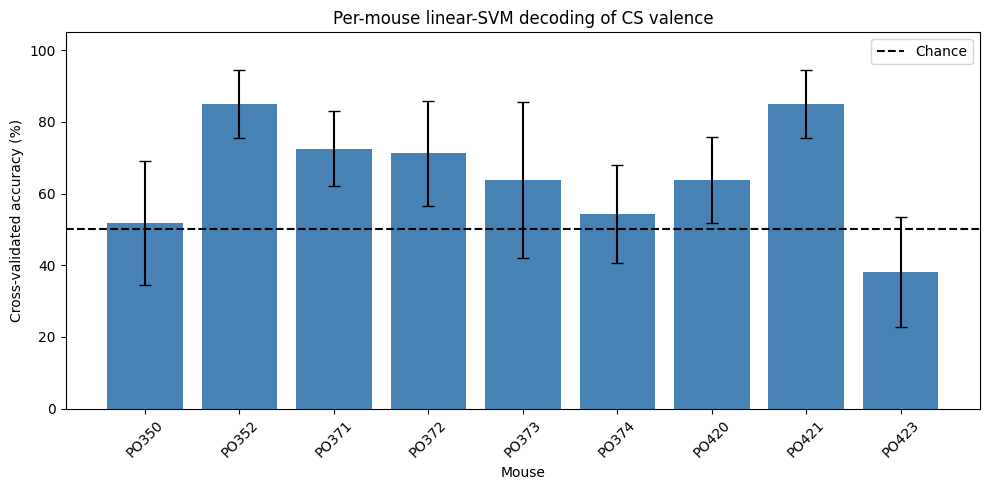

In [24]:
from IPython.display import display
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC

# In the raw metadata, csidentity=0 means CS+ and csidentity=1 means CS−.
# We recode the labels so y=1 means CS+ and y=0 means CS−.

# We will save one final, full-data decoder for each mouse.
mouse_decoders = {}
mouse_results = []

# Repeat a stratified 80/20 split 20 times for each mouse.

for mouse_index, mouse_id in enumerate(mouse_ids):
    session = sessions[mouse_id]

    # Use only trials with recorded activity.
    keep = ~session['silent_trials']
    X = session['X'][keep]
    y = (session['labels']['csidentity'][keep] == 0).astype(int)

    fold_scores = []

    # Use a separate decoder for this mouse; cells from other mice
    # never enter its feature matrix.
    mouse_splitter = StratifiedShuffleSplit(
        n_splits=20, test_size=0.2, random_state=42 + mouse_index
    )
    for train_idx, test_idx in mouse_splitter.split(X, y):
        # Scaling is fitted on training trials inside the pipeline,
        # so test-trial information cannot leak into the decoder.
        decoder = make_pipeline(
            StandardScaler(),
            SVC(kernel='linear', C=1.0),
        )
        decoder.fit(X[train_idx], y[train_idx])
        predictions = decoder.predict(X[test_idx])
        fold_scores.append(accuracy_score(y[test_idx], predictions))

    fold_scores = np.asarray(fold_scores)
    mouse_results.append({
        'mouse': mouse_id,
        'n_trials': len(y),
        'n_cells': X.shape[1],
        'accuracy_mean': fold_scores.mean(),
        'accuracy_sd': fold_scores.std(ddof=1),
    })

    # Keep a final model trained on all trials for this mouse.
    mouse_decoders[mouse_id] = make_pipeline(
        StandardScaler(),
        SVC(kernel='linear', C=1.0),
    ).fit(X, y)

    print(
        f"{mouse_id}: {fold_scores.mean() * 100:.2f}% ± "
        f"{fold_scores.std(ddof=1) * 100:.2f}% SD"
    )

results_df = pd.DataFrame(mouse_results)
print("\nAcross-mouse mean: "
      f"{results_df['accuracy_mean'].mean() * 100:.2f}% ± "
      f"{results_df['accuracy_mean'].std(ddof=1) * 100:.2f}% SD")

display(
    results_df.style.format({
        'accuracy_mean': '{:.1%}',
        'accuracy_sd': '{:.1%}',
    })
)

# Each bar represents one mouse; error bars show variability across splits.
plt.figure(figsize=(10, 5))
plt.bar(
    results_df['mouse'],
    results_df['accuracy_mean'] * 100,
    yerr=results_df['accuracy_sd'] * 100,
    capsize=4,
    color='steelblue',
)
plt.axhline(50, color='black', linestyle='--', label='Chance')
plt.ylim(0, 105)
plt.xlabel('Mouse')
plt.ylabel('Cross-validated accuracy (%)')
plt.title('Per-mouse linear-SVM decoding of CS valence')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 4. References and further resources

1. [Zhang et al., *Cortical regulation of helping behaviour towards others in pain*, Nature 626, 136–144 (2024)](https://doi.org/10.1038/s41586-023-06973-x)
2. [O’Neill et al., *The representational geometry of emotional states in basolateral amygdala*, Nature Neuroscience 29, 1654–1666 (2026)](https://doi.org/10.1038/s41593-026-02315-y)
3. [Bishop, *Pattern Recognition and Machine Learning* (2006), Chapter 3](https://link.springer.com/book/9780387310732)
4. [Behavior and GCaMP data on Figshare](https://figshare.com/articles/dataset/Behavior_and_GCaMP_data/31808005/2?file=62936557)

**Short videos:** [linear regression](https://www.youtube.com/watch?v=7ArmBVF2dCs) · [logistic regression](https://www.youtube.com/watch?v=yIYKR4sgzI8) · [perceptron](https://www.youtube.com/watch?v=4Gac5I64LM4) · [support-vector machines](https://www.youtube.com/watch?v=efR1C6CvhmE)